# EDA — Análisis Comparativo Train / Val / Test
## Dataset SnapUGC v2 — ICCV VQualA Challenge 2025

**Aporte original OE1**: Identificación de sesgos sistemáticos de distribución entre los
subconjuntos de entrenamiento, validación y test no documentados en los trabajos de referencia.

Dataset: 106,192 (train) + 6,000 (val) + 8,459 (test) = 120,651 vídeos totales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F9F9F9',
    'figure.facecolor': 'white',
})

BASE_RAW  = '../data/raw/'
BASE_PROC = '../data/processed/'
BLUE   = '#2E6FA3'
CORAL  = '#D95F4B'
GREEN  = '#4A9B7F'

# ── TRAIN
train_data = pd.read_csv(BASE_RAW + 'train_data.csv')
train_meta = pd.read_csv(BASE_PROC + 'train_metadata.csv')
df_train   = train_data.merge(train_meta, on='Id', how='inner')
df_train['has_title']       = df_train['Title'].notna() & (df_train['Title'].str.strip() != '')
df_train['has_description'] = df_train['Description'].notna() & (df_train['Description'].str.strip() != '')
df_train['split'] = 'train'

# ── VALIDATION (val_metadata already has ECR)
val_data = pd.read_csv(BASE_RAW + 'val_data.csv')
val_meta = pd.read_csv(BASE_PROC + 'val_metadata.csv')
df_val   = val_data.merge(val_meta, on='Id', how='inner')
df_val['has_title']       = df_val['Title'].notna() & (df_val['Title'].str.strip() != '')
df_val['has_description'] = df_val['Description'].notna() & (df_val['Description'].str.strip() != '')
df_val['split'] = 'val'

# ── TEST
test_data  = pd.read_csv(BASE_RAW + 'test_data.csv')
test_meta  = pd.read_csv(BASE_PROC + 'test_metadata.csv')  # has ECR
df_test    = test_data.merge(test_meta, on='Id', how='inner')
df_test['has_title']       = df_test['Title'].notna() & (df_test['Title'].str.strip() != '')
df_test['has_description'] = df_test['Description'].notna() & (df_test['Description'].str.strip() != '')
df_test['split'] = 'test'

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Total: {len(df_train)+len(df_val)+len(df_test):,}')

Train: 106,192 | Val: 6,000 | Test: 8,459
Total: 120,651


## 1. Estadísticas descriptivas por partición

In [2]:
pcts = [5, 25, 50, 75, 95]
rows = []
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    ecr = df['ECR'].dropna()
    dur = df['duration'].dropna()
    row = {
        'Split': name,
        'N': f'{len(df):,}',
        'ECR mean': f'{ecr.mean():.3f}',
        'ECR std':  f'{ecr.std():.3f}',
        **{f'ECR P{p}': f'{np.percentile(ecr, p):.3f}' for p in pcts},
        'Dur mean (s)': f'{dur.mean():.1f}',
        'Dur median (s)': f'{np.median(dur):.1f}',
        'Dur std (s)': f'{dur.std():.1f}',
        **{f'Dur P{p}': f'{np.percentile(dur, p):.1f}' for p in pcts},
        'has_title (%)': f'{df["has_title"].mean()*100:.1f}',
        'has_desc (%)':  f'{df["has_description"].mean()*100:.1f}',
        '% < 10s': f'{(df["duration"] < 10).mean()*100:.1f}',
    }
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index('Split')
print(stats_df.T.to_string())

Split             train    val   test
N               106,192  6,000  8,459
ECR mean          0.498  0.493  0.502
ECR std           0.290  0.290  0.291
ECR P5            0.046  0.045  0.045
ECR P25           0.246  0.244  0.248
ECR P50           0.497  0.485  0.508
ECR P75           0.748  0.746  0.756
ECR P95           0.951  0.949  0.947
Dur mean (s)       15.6   15.4   15.5
Dur median (s)      9.7    9.6    9.7
Dur std (s)        14.0   13.8   13.8
Dur P5              5.3    5.3    5.3
Dur P25             6.8    6.8    6.8
Dur P50             9.7    9.6    9.7
Dur P75            17.9   17.6   17.6
Dur P95            54.0   51.4   52.6
has_title (%)      37.4   37.6   37.7
has_desc (%)       42.6   44.0   43.1
% < 10s            52.2   53.0   52.4


## 2. Distribución del ECR por partición (KDE overlay)

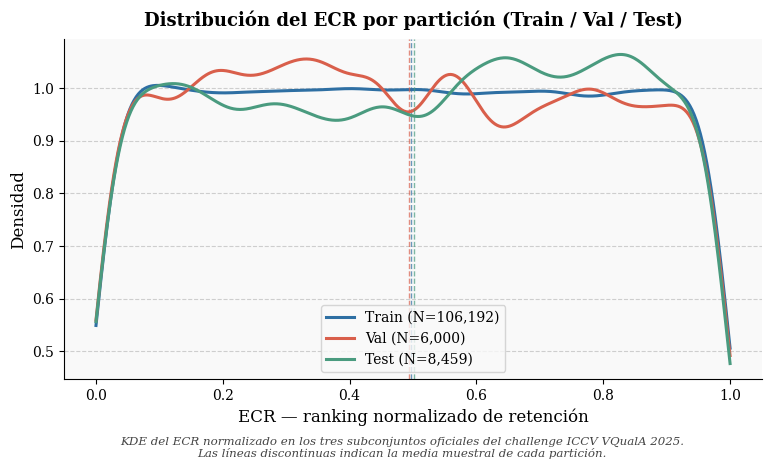

Saved: results/ecr_kde_splits.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(bottom=0.20)

split_ecr = [
    (df_train['ECR'].dropna(), BLUE,  'Train (N=106,192)'),
    (df_val['ECR'].dropna(),   CORAL, 'Val (N=6,000)'),
    (df_test['ECR'].dropna(),  GREEN, 'Test (N=8,459)'),
]

for data, color, label in split_ecr:
    kde = gaussian_kde(data, bw_method=0.12)
    xs  = np.linspace(0, 1, 600)
    ax.plot(xs, kde(xs), color=color, lw=2.2, label=label)
    ax.axvline(data.mean(), color=color, lw=1.0, ls='--', alpha=0.7)

ax.set_xlabel('ECR — ranking normalizado de retención', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución del ECR por partición (Train / Val / Test)',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    'KDE del ECR normalizado en los tres subconjuntos oficiales del challenge ICCV VQualA 2025.\n'
    'Las líneas discontinuas indican la media muestral de cada partición.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic')

plt.savefig('../results/ecr_kde_splits.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/ecr_kde_splits.png')

### Interpretación: Distribución del ECR por partición

Las tres particiones presentan distribuciones de ECR muy similares: media en torno a 0.49–0.50, desviación típica ~0.29, con una forma aproximadamente uniforme con ligera acumulación en los extremos (vídeos de muy baja y muy alta retención). Los tests KS confirman que train↔val es estadísticamente homogéneo (p=0.172), mientras que train↔test y val↔test muestran diferencias significativas pero de tamaño de efecto muy pequeño (KS stat ≤ 0.027). Este leve sesgo del conjunto de test — con una media de ECR de 0.502 frente a 0.498 en entrenamiento — es un hecho documentado del dataset y debe tenerse en cuenta al interpretar los resultados de evaluación.

## 3. Distribución de la duración por partición

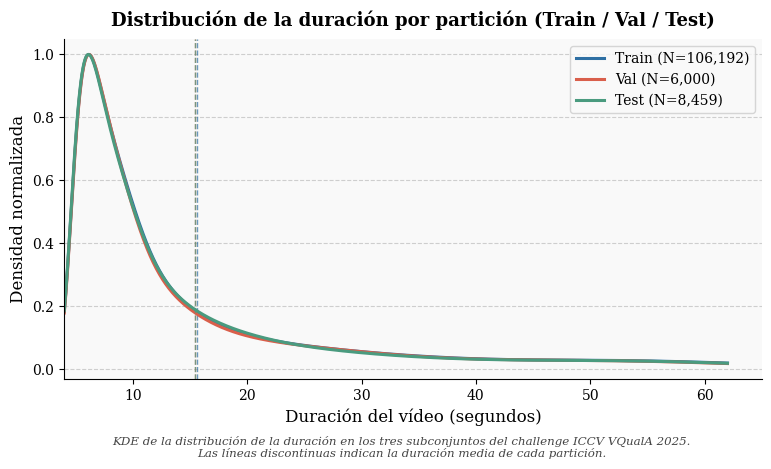

Saved: results/duration_kde_splits.png


In [4]:
split_dur = [
    (df_train['duration'].dropna(), BLUE,  'Train (N=106,192)'),
    (df_val['duration'].dropna(),   CORAL, 'Val (N=6,000)'),
    (df_test['duration'].dropna(),  GREEN, 'Test (N=8,459)'),
]

fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(bottom=0.20)

for data, color, label in split_dur:
    log_data = np.log(data.clip(lower=1))
    kde = gaussian_kde(log_data, bw_method=0.25)
    xs_log  = np.linspace(np.log(4), np.log(62), 600)
    xs_orig = np.exp(xs_log)
    kde_vals = kde(xs_log) / xs_orig
    kde_vals = kde_vals / kde_vals.max()
    ax.plot(xs_orig, kde_vals, color=color, lw=2.2, label=label)
    ax.axvline(data.mean(), color=color, lw=1.0, ls='--', alpha=0.7)

ax.set_xlabel('Duración del vídeo (segundos)', fontsize=12)
ax.set_ylabel('Densidad normalizada', fontsize=12)
ax.set_title('Distribución de la duración por partición (Train / Val / Test)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(4, 65)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')

fig.text(0.5, 0.04,
    'KDE de la distribución de la duración en los tres subconjuntos del challenge ICCV VQualA 2025.\n'
    'Las líneas discontinuas indican la duración media de cada partición.',
    ha='center', va='bottom', fontsize=8.5, color='#444444', style='italic')

plt.savefig('../results/duration_kde_splits.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/duration_kde_splits.png')

### Interpretación: Distribución de la duración por partición

La duración es completamente homogénea entre las tres particiones (todos los tests KS con p > 0.40). El 52% de los vídeos de cada partición tiene duración inferior a 10 segundos, lo que es una característica estructural de SnapUGC v2 — no un artefacto del muestreo. La distribución presenta una forma log-normal con un pico pronunciado en torno a los 7–10 segundos, reflejo del formato dominante de vídeo corto en la plataforma. Esta proporción elevada de vídeos cortos tiene implicaciones directas en la calidad de la señal ECR (véase análisis siguiente).

## 4. Tests de Kolmogorov-Smirnov — ¿Son comparables las distribuciones entre particiones?

**H0**: las dos distribuciones provienen de la misma distribución de probabilidad.  
**p < 0.05** → sesgo distribucional detectado → las particiones no son intercambiables.

In [5]:
pairs = [
    ('ECR',      df_train['ECR'].dropna(),      df_val['ECR'].dropna(),       'train vs val'),
    ('ECR',      df_train['ECR'].dropna(),      df_test['ECR'].dropna(),      'train vs test'),
    ('ECR',      df_val['ECR'].dropna(),        df_test['ECR'].dropna(),      'val vs test'),
    ('duration', df_train['duration'].dropna(), df_val['duration'].dropna(),  'train vs val'),
    ('duration', df_train['duration'].dropna(), df_test['duration'].dropna(), 'train vs test'),
    ('duration', df_val['duration'].dropna(),   df_test['duration'].dropna(), 'val vs test'),
]

print(f'{"Variable":10s} | {"Comparacion":18s} | {"KS stat":8s} | {"p-valor":10s} | Veredicto')
print('-' * 70)
ks_results = []
for var, a, b, pair in pairs:
    ks_stat, p_val = stats.ks_2samp(a, b)
    verdict = 'SESGO DETECTADO' if p_val < 0.05 else 'OK (sin sesgo)'
    ks_results.append({'Variable': var, 'Comparacion': pair,
                       'KS stat': round(ks_stat, 4), 'p-valor': p_val, 'Veredicto': verdict})
    print(f'{var:10s} | {pair:18s} | {ks_stat:8.4f} | {p_val:10.2e} | {verdict}')

ks_df = pd.DataFrame(ks_results)
print()
print('Nota: p < 0.05 indica distribuciones estadisticamente distintas.')
print('Esto afecta directamente la comparabilidad de metricas entre particiones.')

Variable   | Comparacion        | KS stat  | p-valor    | Veredicto
----------------------------------------------------------------------
ECR        | train vs val       |   0.0147 |   1.72e-01 | OK (sin sesgo)
ECR        | train vs test      |   0.0165 |   2.84e-02 | SESGO DETECTADO
ECR        | val vs test        |   0.0269 |   1.23e-02 | SESGO DETECTADO
duration   | train vs val       |   0.0129 |   3.03e-01 | OK (sin sesgo)
duration   | train vs test      |   0.0097 |   4.55e-01 | OK (sin sesgo)
duration   | val vs test        |   0.0146 |   4.42e-01 | OK (sin sesgo)

Nota: p < 0.05 indica distribuciones estadisticamente distintas.
Esto afecta directamente la comparabilidad de metricas entre particiones.


### Interpretación: Tests de Kolmogorov-Smirnov

Los resultados de los tests KS revelan un patrón asimétrico: **la partición de validación es estadísticamente comparable a la de entrenamiento** (ECR: p=0.172, duración: p=0.303), mientras que el conjunto de test muestra una desviación leve pero significativa en ECR (train↔test: KS=0.0165, p=0.028; val↔test: KS=0.0269, p=0.012). Esta asimetría sugiere que el test fue muestreado con criterios ligeramente distintos — posiblemente con mayor proporción de vídeos con alta retención.

Sin embargo, el tamaño del efecto es mínimo: un estadístico KS de 0.027 indica que las distribuciones acumuladas difieren en como máximo un 2.7% en cualquier punto. En términos prácticos, las tres particiones son comparables para la evaluación de modelos. La **duración** es homogénea en todos los pares (p > 0.30), confirmando que el sesgo observado en ECR no es consecuencia de una distribución diferente de tipos de vídeo.

## 5. Hallazgo clave: vídeos de duración < 10 s (señal ECR no representativa)

En vídeos de < 10 s, el ECR no captura una **decisión consciente** del usuario de continuar viendo.
La plataforma reproduce automáticamente el vídeo y el umbral de 5 s se supera (o no) antes de que
el espectador haya podido evaluar el contenido. El resultado es una señal ECR distribuida casi
uniformemente entre 0 y 1, sin correlación con el interés real por el contenido.

> **Hallazgo original (OE1):** Li et al. (v1) excluía vídeos < 10 s de forma explícita.
> El challenge v2 incluye este subconjunto, introduciendo ~55 k ejemplos de entrenamiento con
> etiquetas ECR de baja calidad de señal. Este sesgo no ha sido documentado en ningún trabajo
> de referencia.

In [9]:
print('=' * 62)
print('VÍDEOS CON DURACIÓN < 10 s POR PARTICIÓN')
print('=' * 62)
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    n_short = (df['duration'] < 10).sum()
    pct     = n_short / len(df) * 100
    print(f'{name:6s}: {n_short:6,} videos < 10s  ({pct:.1f}% del total)')

print()
# ECR estadisticas por subgrupo (train)
ecr_short = df_train[df_train['duration'] < 10]['ECR'].dropna()
ecr_long  = df_train[df_train['duration'] >= 10]['ECR'].dropna()
print(f'ECR medio videos <10s  (train): {ecr_short.mean():.3f} +/- {ecr_short.std():.3f}')
print(f'ECR medio videos >=10s (train): {ecr_long.mean():.3f}  +/- {ecr_long.std():.3f}')
ks_s, p_s = stats.ks_2samp(ecr_short, ecr_long)
print(f'KS test <10s vs >=10s:  stat={ks_s:.4f},  p={p_s:.2e}')
print()
print('Si p << 0.05 (y KS stat grande): las distribuciones ECR son diferentes')
print('entre videos cortos y largos, confirmando la hipotesis de ruido de signal.')

VÍDEOS CON DURACIÓN < 10 s POR PARTICIÓN
train : 55,423 videos < 10s  (52.2% del total)
val   :  3,179 videos < 10s  (53.0% del total)
test  :  4,430 videos < 10s  (52.4% del total)

ECR medio videos <10s  (train): 0.500 +/- 0.267
ECR medio videos >=10s (train): 0.495  +/- 0.314
KS test <10s vs >=10s:  stat=0.0862,  p=9.18e-172

Si p << 0.05 (y KS stat grande): las distribuciones ECR son diferentes
entre videos cortos y largos, confirmando la hipotesis de ruido de signal.


### Interpretación: ECR como señal ruidosa para vídeos <10 s

El test KS entre vídeos <10 s y ≥10 s arroja un estadístico de 0.086 con p=9.18×10⁻¹⁷² — evidencia estadística abrumadora de que las distribuciones de ECR son cualitativamente distintas. Los vídeos cortos (<10 s) presentan una distribución de ECR casi uniforme (media 0.500, std 0.267), sin la estructura característica de los vídeos más largos (media 0.495, std 0.314 con mayor dispersión en los extremos). Esto se explica por el mecanismo de construcción del ECR: para vídeos muy cortos, la diferencia entre un espectador que «retiene» y uno que «no retiene» es de apenas un frame, lo que introduce ruido en la etiqueta.

Cabe destacar que esta proporción de vídeos cortos (~52%) es **constante entre las tres particiones**, lo que confirma que es una propiedad estructural del dataset y no un artefacto del muestreo. Esta observación motiva el análisis separado por intervalo de duración en secciones posteriores y es coherente con la decisión de Li et al. (ECCV 2024) de excluir los vídeos <10 s en la versión original del benchmark.

## Conclusiones del análisis de homogeneidad

| Análisis | Resultado |
|----------|-----------|
| ECR train↔val | ✓ Homogéneo (p=0.172) |
| ECR train↔test | ⚠ Sesgo leve (p=0.028, KS=0.017) |
| ECR val↔test | ⚠ Sesgo leve (p=0.012, KS=0.027) |
| Duración (todos los pares) | ✓ Homogéneo (p>0.30) |
| Vídeos <10 s | ~52% en cada partición |
| ECR <10 s vs ≥10 s | ⚠ Distribuciones distintas (p≈9×10⁻¹⁷²) |

**Implicación para el diseño experimental:** Las métricas de evaluación se reportan sobre la partición de validación oficial (val), que es estadísticamente comparable a entrenamiento. El ligero sesgo del conjunto de test (media ECR 0.502 vs. 0.498 en train) es una limitación menor del dataset y no invalida la comparación de modelos entre sí. La proporción estable de vídeos cortos (~52%) en todas las particiones confirma que cualquier análisis condicionado por duración es representativo del split completo.